In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from collections import Counter
import re


In [2]:
df=pd.read_csv(r'DataNeuron_Text_Similarity.csv')
df

,text1,text2
0,broadband challenges tv viewing the number of ...,gardener wins double in glasgow britain s jaso...
1,rap boss arrested over drug find rap mogul mar...,amnesty chief laments war failure the lack of ...
2,player burn-out worries robinson england coach...,hanks greeted at wintry premiere hollywood sta...
3,hearts of oak 3-2 cotonsport hearts of oak set...,redford s vision of sundance despite sporting ...
4,sir paul rocks super bowl crowds sir paul mcca...,mauresmo opens with victory in la amelie maure...
...,...,...
2995,uk directors guild nominees named martin scors...,steel firm to cut 45 000 jobs mittal steel ...
2996,u2 to play at grammy awards show irish rock ba...,israel looks to us for bank chief israel has a...
2997,pountney handed ban and fine northampton coach...,india and iran in gas export deal india has si...
2998,belle named best scottish band belle & sebas...,mido makes third apology ahmed mido hossam h...


In [3]:
df.describe()

,text1,text2
count,3000,3000
unique,1277,1256
top,stars pay tribute to actor davis hollywood sta...,edwards tips idowu for euro gold world outdoor...
freq,9,12


In [4]:
# Checking for duplicate values
print(f'text1 column duplicates value count : {df["text1"].duplicated().sum()}')
print(f'text2 column duplicates value count : {df["text2"].duplicated().sum()}')

text1 column duplicates value count : 1723
text2 column duplicates value count : 1744


In [5]:
# Checking for duplicate pairs
print("Exact duplicate rows:", df.duplicated(subset=['text1', 'text2']).sum())

Exact duplicate rows: 1


In [6]:
# Checking if any missing values
print(df.isnull().sum())

text1    0
text2    0
dtype: int64


In [7]:
df['text1'][0]

'broadband challenges tv viewing the number of europeans with broadband has exploded over the past 12 months  with the web eating into tv viewing habits  research suggests.  just over 54 million people are hooked up to the net via broadband  up from 34 million a year ago  according to market analysts nielsen/netratings. the total number of people online in europe has broken the 100 million mark. the popularity of the net has meant that many are turning away from tv  say analysts jupiter research. it found that a quarter of web users said they spent less time watching tv in favour of the net  the report by nielsen/netratings found that the number of people with fast internet access had risen by 60% over the past year.  the biggest jump was in italy  where it rose by 120%. britain was close behind  with broadband users almost doubling in a year. the growth has been fuelled by lower prices and a wider choice of always-on  fast-net subscription plans.  twelve months ago high speed internet

In [8]:
df['text2'][0]

'gardener wins double in glasgow britain s jason gardener enjoyed a double 60m success in glasgow in his first competitive outing since he won 100m relay gold at the athens olympics.  gardener cruised home ahead of scot nick smith to win the invitational race at the norwich union international. he then recovered from a poor start in the second race to beat swede daniel persson and italy s luca verdecchia. his times of 6.61 and 6.62 seconds were well short of american maurice greene s 60m world record of 6.39secs from 1998.  it s a very hard record to break  but i believe i ve trained very well   said the world indoor champion  who hopes to get closer to the mark this season.  it was important to come out and make sure i got maximum points. my last race was the olympic final and there was a lot of expectation.  this was just what i needed to sharpen up and get some race fitness. i m very excited about the next couple of months.   double olympic champion  marked her first appearance on h

In [11]:
# length of each text from both columns
no_of_words_text1=[len(i.split()) for i in df['text1']]
no_of_words_text2=[len(i.split()) for i in df['text2']]

# Average number of words 
no_of_words_text1_avg=sum(no_of_words_text1)/len(df['text1'])
no_of_words_text2_avg=sum(no_of_words_text2)/len(df['text2'])

print(f'Average number of words in text1 column : {no_of_words_text1_avg}')
print(f'Average number of words in text2 column : {no_of_words_text2_avg}')

Average number of words in text1 column : 393.78266666666667
Average number of words in text2 column : 398.6123333333333


In [51]:
# Word count from all the data including column text1 and text2

# Example: Combine both columns if you have 'text1' and 'text2'
all_text = ' '.join(df['text1'].fillna('')) + ' ' + ' '.join(df['text2'].fillna(''))

# Optional: lowercase and remove punctuation
all_text = all_text.lower()
all_text = re.sub(r'[^a-z\s]', '', all_text)

# Tokenize and count word frequencies
word_list = all_text.split()
word_counts = Counter(word_list)

# Display top 20 most common words
print("Top 20 Repeated Words:")
for word, count in list(word_counts.most_common()):
    print(f"{word}: {count}")


Top 20 Repeated Words:
the: 143145
to: 68871
of: 54632
and: 50940
a: 49780
in: 48139
s: 25766
is: 24304
for: 24242
that: 22364
it: 21787
on: 20558
said: 19638
was: 16774
he: 16452
be: 16277
with: 14578
as: 13700
has: 13420
have: 12802
at: 12524
by: 12277
but: 12208
will: 12198
are: 12197
i: 10783
not: 9717
from: 9608
they: 8372
his: 8324
mr: 8187
we: 8128
this: 7691
an: 7650
would: 7270
which: 6971
had: 6929
been: 6740
their: 6701
more: 6363
its: 6061
who: 5956
people: 5847
also: 5773
were: 5711
up: 5643
new: 5363
there: 5306
about: 5070
m: 5025
year: 4981
us: 4957
can: 4748
one: 4673
after: 4621
or: 4521
out: 4520
if: 4392
than: 4275
all: 4141
you: 4092
could: 4089
over: 3896
last: 3683
when: 3634
t: 3501
government: 3395
first: 3315
world: 3253
she: 3172
what: 3140
into: 3124
two: 3121
time: 3120
some: 3114
other: 3094
so: 3055
now: 2938
film: 2768
uk: 2752
against: 2668
years: 2640
do: 2635
just: 2600
only: 2575
make: 2558
being: 2534
game: 2508
them: 2507
music: 2502
no: 2468
told:

In [39]:
len(word_counts.most_common())

25737

In [73]:
list(word_counts.most_common())[100:300]

[('many', 2253),
 ('before', 2234),
 ('because', 2215),
 ('like', 2201),
 ('her', 2197),
 ('bbc', 2172),
 ('while', 2137),
 ('any', 2118),
 ('take', 2113),
 ('next', 2105),
 ('number', 2097),
 ('most', 2069),
 ('back', 2062),
 ('added', 1975),
 ('three', 1953),
 ('company', 1949),
 ('my', 1946),
 ('set', 1924),
 ('well', 1921),
 ('way', 1893),
 ('may', 1869),
 ('our', 1851),
 ('then', 1832),
 ('work', 1813),
 ('still', 1808),
 ('home', 1795),
 ('him', 1792),
 ('says', 1779),
 ('market', 1777),
 ('firm', 1751),
 ('those', 1743),
 ('going', 1741),
 ('election', 1740),
 ('good', 1715),
 ('england', 1714),
 ('say', 1710),
 ('win', 1686),
 ('go', 1683),
 ('show', 1682),
 ('much', 1666),
 ('since', 1662),
 ('down', 1662),
 ('games', 1648),
 ('party', 1645),
 ('how', 1642),
 ('public', 1635),
 ('off', 1620),
 ('million', 1599),
 ('blair', 1582),
 ('play', 1572),
 ('think', 1563),
 ('between', 1533),
 ('won', 1529),
 ('want', 1528),
 ('both', 1525),
 ('week', 1511),
 ('minister', 1504),
 ('par

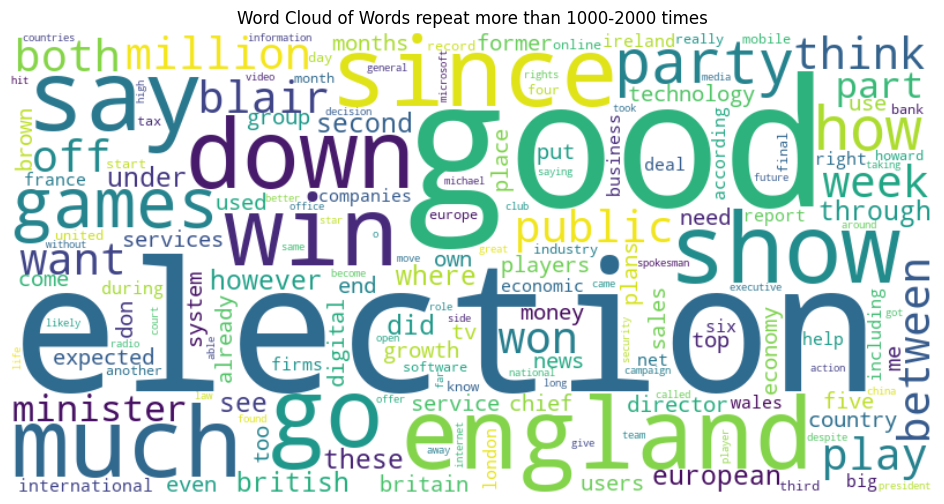

In [76]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Get most important common words that repeat more than 1000-2000 times
top_words = dict(list(word_counts.most_common())[132:300])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_words)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Words repeat more than 1000-2000 times")
plt.show()


In [59]:
# The topics involve around as they are most repeating words

'''
week: 1511
minister: 1504
part: 1500
through: 1492
however: 1479
where: 1473
did: 1461
under: 1458
european: 1447
british: 1437
these: 1436
see: 1426
second: 1425
technology: 1418
use: 1413
top: 1406
players: 1389
country: 1389
growth: 1372
plans: 1372
sales: 1369
service: 1365
expected: 1359
tv: 1346
me: 1335
former: 1333
news: 1329
brown: 1329
group: 1328
britain: 1317
too: 1313
economy: 1294
put: 1293
end: 1292
director: 1290
even: 1277
don: 1275
five: 1274
system: 1274
used: 1269
services: 1264
chief: 1250
digital: 1242
already: 1239
months: 1234
come: 1223
own: 1213
users: 1210
place: 1180
money: 1179
need: 1175
companies: 1169
during: 1162
including: 1159
according: 1154
france: 1151
big: 1146
london: 1141
deal: 1130
net: 1127
right: 1123
six: 1121
report: 1119
firms: 1111
help: 1110
ireland: 1109
international: 1104
wales: 1104
economic: 1095
business: 1087
industry: 1084
day: 1080
mobile: 1079
another: 1079
software: 1075
'''

'\nweek: 1511\nminister: 1504\npart: 1500\nthrough: 1492\nhowever: 1479\nwhere: 1473\ndid: 1461\nunder: 1458\neuropean: 1447\nbritish: 1437\nthese: 1436\nsee: 1426\nsecond: 1425\ntechnology: 1418\nuse: 1413\ntop: 1406\nplayers: 1389\ncountry: 1389\ngrowth: 1372\nplans: 1372\nsales: 1369\nservice: 1365\nexpected: 1359\ntv: 1346\nme: 1335\nformer: 1333\nnews: 1329\nbrown: 1329\ngroup: 1328\nbritain: 1317\ntoo: 1313\neconomy: 1294\nput: 1293\nend: 1292\ndirector: 1290\neven: 1277\ndon: 1275\nfive: 1274\nsystem: 1274\nused: 1269\nservices: 1264\nchief: 1250\ndigital: 1242\nalready: 1239\nmonths: 1234\ncome: 1223\nown: 1213\nusers: 1210\nplace: 1180\nmoney: 1179\nneed: 1175\ncompanies: 1169\nduring: 1162\nincluding: 1159\naccording: 1154\nfrance: 1151\nbig: 1146\nlondon: 1141\ndeal: 1130\nnet: 1127\nright: 1123\nsix: 1121\nreport: 1119\nfirms: 1111\nhelp: 1110\nireland: 1109\ninternational: 1104\nwales: 1104\neconomic: 1095\nbusiness: 1087\nindustry: 1084\nday: 1080\nmobile: 1079\nanother: 

### Longformer Model - 4096 Token Limit

In [12]:
# We are trying a model that supports token size of 4096

from sentence_transformers import SentenceTransformer, util

# Load a long-input model (Longformer, BigBird, etc.)
model = SentenceTransformer("allenai/longformer-base-4096")  # or a SBERT variant if you find one

# Example long inputs from two cells
text1_0 = df['text1'][0]
text2_0 = df['text2'][0]

# Encode each separately
embedding1 = model.encode(text1_0, convert_to_tensor=True)
embedding2 = model.encode(text2_0, convert_to_tensor=True)

# Compute similarity
similarity_score = util.cos_sim(embedding1, embedding2).item()

print(f"Similarity Score: {similarity_score:.4f}")

No sentence-transformers model found with name allenai/longformer-base-4096. Creating a new one with mean pooling.
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


Similarity Score: 0.9776


### All-MiniLM-L6-v2 Model - 512 Token Limit 

In [13]:
# Load pretrained model that supports token size of 512
model = SentenceTransformer('all-MiniLM-L6-v2')

# Assinging Variables to use first values from each columns
text1_0=df['text1'][0]
text2_0=df['text2'][0]

# Encode the Texts
embeddings = model.encode([text1_0, text2_0])

# Retrieve the similarity value
similarity = util.cos_sim(embeddings[0], embeddings[1])
print(f'Similarity Score Between text1_0 and text2_0 is {float(similarity)}')

Similarity Score Between text1_0 and text2_0 is 0.08618979901075363


In [14]:
similarity_score={}

for i in range(len(df['text1'])):
    text1_i=df['text1'][i]
    text2_i=df['text2'][i]

    embeddings = model.encode([text1_i, text2_i])
    similarity = float(util.cos_sim(embeddings[0], embeddings[1]))
    similarity_score[i]=similarity

In [15]:
similarity_score

{0: 0.08618979901075363,
 1: 0.1654796302318573,
 2: 0.07780099660158157,
 3: -0.18615230917930603,
 4: 0.08868970721960068,
 5: -0.0332813560962677,
 6: -0.015375801362097263,
 7: 0.010286912322044373,
 8: 0.011737337335944176,
 9: -0.01264222152531147,
 10: 0.11060731112957001,
 11: 0.08700771629810333,
 12: 0.281890332698822,
 13: 0.268451452255249,
 14: -0.04105183482170105,
 15: -0.06720378994941711,
 16: 0.20090293884277344,
 17: 0.28801557421684265,
 18: 0.15817254781723022,
 19: 0.13377231359481812,
 20: 0.1341027319431305,
 21: 0.08177504688501358,
 22: 0.03955790773034096,
 23: 0.004862908273935318,
 24: 0.11844970285892487,
 25: 0.12490721046924591,
 26: 0.07030807435512543,
 27: 0.11436575651168823,
 28: 0.1587163656949997,
 29: 0.07198406755924225,
 30: 0.16492092609405518,
 31: 0.15825863182544708,
 32: 0.22580090165138245,
 33: 0.06306371092796326,
 34: 0.07342200726270676,
 35: 0.16306819021701813,
 36: 0.06273621320724487,
 37: 0.1900811344385147,
 38: 0.16307970881462

In [16]:
[j for i,j in similarity_score.items() if j<0]

[-0.18615230917930603,
 -0.0332813560962677,
 -0.015375801362097263,
 -0.01264222152531147,
 -0.04105183482170105,
 -0.06720378994941711,
 -0.1149897649884224,
 -0.007758224382996559,
 -0.05221934989094734,
 -0.0052171433344483376,
 -0.023399904370307922,
 -0.011675700545310974,
 -0.055547941476106644,
 -0.03850767761468887,
 -0.0006798356771469116,
 -0.08735517412424088,
 -0.06591752916574478,
 -0.012623392045497894,
 -0.09910543262958527,
 -0.0691784918308258,
 -0.030102761462330818,
 -0.0985601544380188,
 -0.015296394005417824,
 -0.020838048309087753,
 -0.027365613728761673,
 -0.018629873171448708,
 -0.02010168880224228,
 -0.09018124639987946,
 -0.00747554749250412,
 -0.012057505548000336,
 -0.03491973876953125,
 -0.012623302638530731,
 -0.02157694101333618,
 -0.148884117603302,
 -0.042607977986335754,
 -0.014986731112003326,
 -0.07744001597166061,
 -0.04573745280504227,
 -0.03428050875663757,
 -0.11026786267757416,
 -0.013631168752908707,
 -0.015423968434333801,
 -0.056462857872247

In [17]:
# Understanding the distribution of Predicted SImilarity Scores

print(len([j for i,j in similarity_score.items() if j<-0.2]))
print(len([j for i,j in similarity_score.items() if j<-0.1]))
print(len([j for i,j in similarity_score.items() if j<-0.05]))
print(len([j for i,j in similarity_score.items() if j<0]))
print(len([j for i,j in similarity_score.items() if j>0]))
print(len([j for i,j in similarity_score.items() if j>0.1]))
print(len([j for i,j in similarity_score.items() if j>0.2]))
print(len([j for i,j in similarity_score.items() if j>0.4]))
print(len([j for i,j in similarity_score.items() if j>0.5]))

0
32
137
421
2579
1464
644
77
23


In [18]:
# To scale similarity score from 0 to 1 
similarity_score={}

for i in range(len(df['text1'])):
    text1_i=df['text1'][i]
    text2_i=df['text2'][i]

    embeddings = model.encode([text1_i, text2_i])
    similarity = float(util.cos_sim(embeddings[0], embeddings[1]))
    
    # Scaled from 0 to 1
    similarity = (similarity + 1) / 2
    
    similarity_score[i]=similarity  

In [19]:
similarity_score

{0: 0.5430948995053768,
 1: 0.5827398151159286,
 2: 0.5389004983007908,
 3: 0.406923845410347,
 4: 0.5443448536098003,
 5: 0.48335932195186615,
 6: 0.49231209931895137,
 7: 0.5051434561610222,
 8: 0.5058686686679721,
 9: 0.49367888923734426,
 10: 0.555303655564785,
 11: 0.5435038581490517,
 12: 0.640945166349411,
 13: 0.6342257261276245,
 14: 0.4794740825891495,
 15: 0.46639810502529144,
 16: 0.6004514694213867,
 17: 0.6440077871084213,
 18: 0.5790862739086151,
 19: 0.5668861567974091,
 20: 0.5670513659715652,
 21: 0.5408875234425068,
 22: 0.5197789538651705,
 23: 0.5024314541369677,
 24: 0.5592248514294624,
 25: 0.562453605234623,
 26: 0.5351540371775627,
 27: 0.5571828782558441,
 28: 0.5793581828474998,
 29: 0.5359920337796211,
 30: 0.5824604630470276,
 31: 0.5791293159127235,
 32: 0.6129004508256912,
 33: 0.5315318554639816,
 34: 0.5367110036313534,
 35: 0.5815340951085091,
 36: 0.5313681066036224,
 37: 0.5950405672192574,
 38: 0.5815398544073105,
 39: 0.5165157616138458,
 40: 0.560

In [34]:
# Distribution of Similarity Scores
print(len([j for i,j in similarity_score.items() if j<0.1]))
print(len([j for i,j in similarity_score.items() if j>0.1 and j<0.2]))
print(len([j for i,j in similarity_score.items() if j>0.2 and j<0.3]))
print(len([j for i,j in similarity_score.items() if j>0.3 and j<0.4]))
print(len([j for i,j in similarity_score.items() if j>0.4 and j<0.5]))
print(len([j for i,j in similarity_score.items() if j>0.5 and j<0.6]))
print(len([j for i,j in similarity_score.items() if j>0.6 and j<0.7]))
print(len([j for i,j in similarity_score.items() if j>0.7 and j<0.8]))
print(len([j for i,j in similarity_score.items() if j>0.8 and j<0.9]))
print(len([j for i,j in similarity_score.items() if j>0.9 and j<0.95]))
print(len([j for i,j in similarity_score.items() if j>0.95 and j<0.975]))
print(len([j for i,j in similarity_score.items() if j>0.975]))

0
0
0
0
421
1935
567
71
4
0
0
2


C:\Users\jnoot\AppData\Local\Temp\ipykernel_12336\3502430840.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=labels, y=counts, palette="Blues_d")


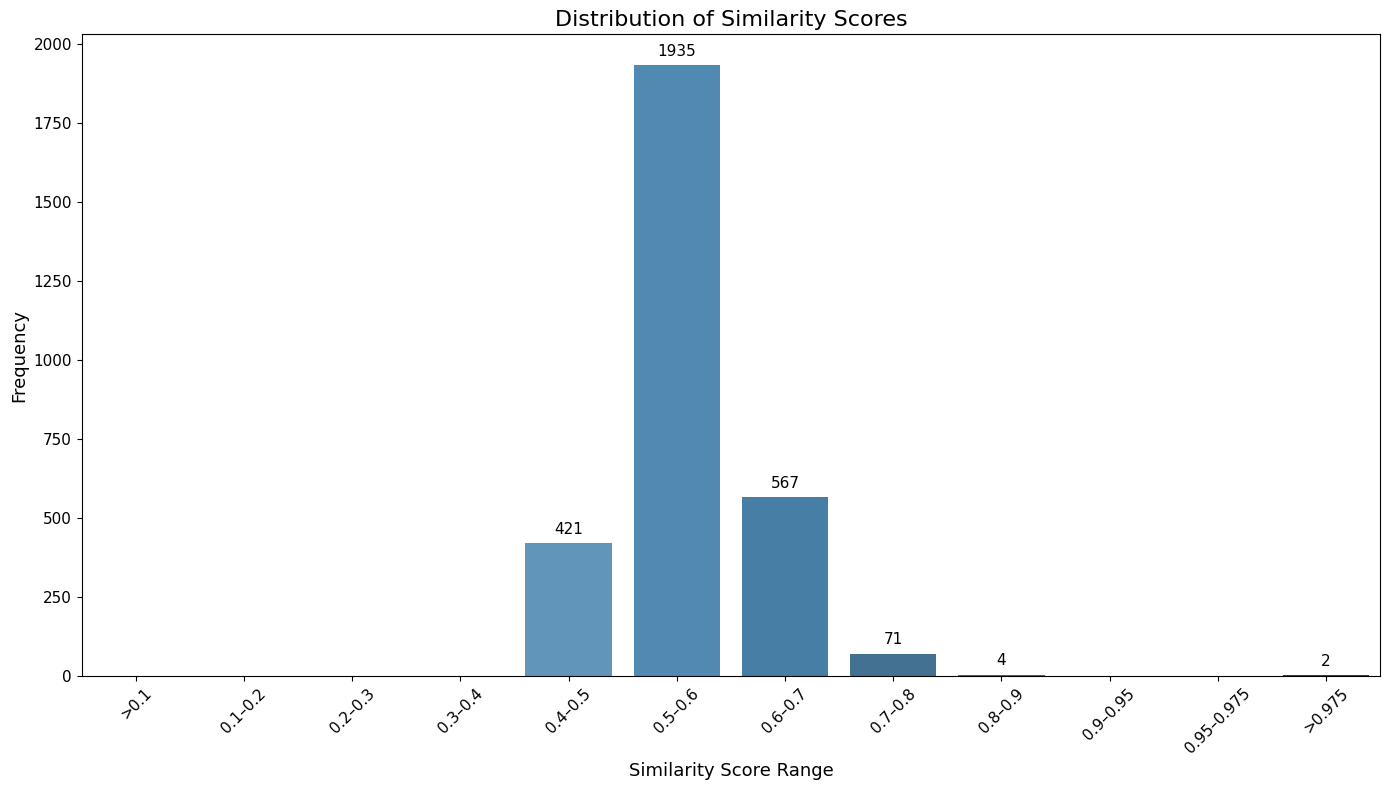

In [33]:
# Distribution of the Similarity Scores Visualized

import matplotlib.pyplot as plt
import seaborn as sns

# Manually count per bin as per your prints
counts = [
    len([j for i, j in similarity_score.items() if j < 0.1]),
    len([j for i, j in similarity_score.items() if 0.1 < j < 0.2]),
    len([j for i, j in similarity_score.items() if 0.2 < j < 0.3]),
    len([j for i, j in similarity_score.items() if 0.3 < j < 0.4]),
    len([j for i, j in similarity_score.items() if 0.4 < j < 0.5]),
    len([j for i, j in similarity_score.items() if 0.5 < j < 0.6]),
    len([j for i, j in similarity_score.items() if 0.6 < j < 0.7]),
    len([j for i, j in similarity_score.items() if 0.7 < j < 0.8]),
    len([j for i, j in similarity_score.items() if 0.8 < j < 0.9]),
    len([j for i, j in similarity_score.items() if 0.9 < j < 0.95]),
    len([j for i, j in similarity_score.items() if 0.95 < j < 0.975]),
    len([j for i, j in similarity_score.items() if j > 0.975])
]

labels = [
    '>0.1', '0.1–0.2', '0.2–0.3', '0.3–0.4', '0.4–0.5',
    '0.5–0.6', '0.6–0.7', '0.7–0.8', '0.8–0.9', '0.9–0.95',
    '0.95–0.975', '>0.975'
]

# Plot
plt.figure(figsize=(14, 8))
bars = sns.barplot(x=labels, y=counts, palette="Blues_d")

# Add counts on top of bars
for bar, count in zip(bars.patches, counts):
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 20,
                 str(count), ha='center', va='bottom', color='black', fontsize=11)

plt.title('Distribution of Similarity Scores', fontsize=16)
plt.xlabel('Similarity Score Range', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


In [34]:
# Checking Similarity Manually
[i for i,j in similarity_score.items() if j>0.8 and j<0.9]

[251, 1523, 2113, 2988]

In [41]:
# Checking Similarity Manually
df['text1'][2113]

'tsunami to cost sri lanka $1.3bn sri lanka faces a $1.3bn (£691m) bill in 2005 for reconstruction after the tsunami which killed more than 30 000 of its people  its central bank says.  this estimate is preliminary  bank governor sunil mendis told reporters  and could rise in 2006. the island state is asking for about $320m from the international monetary fund to help pay for relief  he said. the bank has 5bn rupees ($50m; £27m) set aside to lend at a lower interest rate to those who lost property. according to mr mendis  half the imf support could come from a freeze on debt repayments  which would free up resources immediately. the rest could come from a five-year emergency loan. sri lanka is hoping for a wider freeze from other creditors.  the paris club of 19 creditors meets on 12 january to discuss a debt moratorium for the nations hit by the tsunami  which ravaged south and east asia on 26 december.  some 150 000 people across the region are feared to be dead and millions have bee

In [42]:
df['text2'][2113]

'asia quake increases poverty risk nearly two million people across asia could be thrown into poverty because of the indian ocean tsunami  the asian development bank (adb) has said.  in its first overview of the disaster  the adb said the impact on economic growth would be slight because major cities and factories escaped damage. but the blow to many low-income people could be  enormous . the paris club of rich creditor nations on wednesday offered to freeze debts owed by tsunami-hit countries.  the move was aimed at helping south asian governments find budgets to rebuild devastated coastal areas  though so far only sri lanka  indonesia and the seychelles have indicated that they will take it up.  other countries believe their economies are strong enough to cope or wish to avoid being viewed as credit risks.  poverty is potentially the most important impact of this natural disaster   said adb chief economist ifzal ali. donor nations have promised to give $717m (£379m) in disaster relie

In [43]:
similarity_score[2113]

0.8498639464378357

In [35]:
[i for i,j in similarity_score.items() if j>0.6 and j<0.7]

[12,
 13,
 16,
 17,
 32,
 46,
 50,
 53,
 55,
 56,
 64,
 65,
 70,
 73,
 74,
 79,
 80,
 82,
 95,
 103,
 112,
 121,
 126,
 132,
 135,
 146,
 150,
 161,
 176,
 178,
 179,
 192,
 206,
 209,
 214,
 220,
 221,
 227,
 228,
 231,
 247,
 260,
 263,
 272,
 274,
 275,
 279,
 281,
 289,
 290,
 298,
 306,
 307,
 308,
 309,
 317,
 318,
 320,
 322,
 336,
 338,
 343,
 350,
 351,
 357,
 361,
 363,
 365,
 373,
 388,
 398,
 401,
 404,
 411,
 417,
 435,
 437,
 438,
 446,
 449,
 450,
 451,
 455,
 462,
 464,
 466,
 472,
 476,
 477,
 491,
 498,
 502,
 503,
 506,
 507,
 509,
 511,
 515,
 517,
 520,
 522,
 524,
 530,
 533,
 543,
 546,
 549,
 555,
 556,
 557,
 559,
 562,
 565,
 585,
 587,
 590,
 591,
 601,
 602,
 604,
 609,
 612,
 625,
 626,
 631,
 632,
 635,
 652,
 660,
 663,
 665,
 667,
 672,
 673,
 674,
 675,
 676,
 679,
 680,
 682,
 683,
 684,
 689,
 690,
 694,
 701,
 722,
 725,
 733,
 738,
 745,
 752,
 757,
 760,
 768,
 769,
 774,
 775,
 776,
 777,
 778,
 781,
 784,
 800,
 805,
 807,
 809,
 811,
 812,
 813,

In [39]:
df['text1'][50]

'broadband fuels online expression fast web access is encouraging more people to express themselves online  research suggests.  a quarter of broadband users in britain regularly upload content and have personal sites  according to a report by uk think-tank demos. it said that having an always-on  fast connection is changing the way people use the internet. more than five million households in the uk have broadband and that number is growing fast.  the demos report looked at the impact of broadband on people s net habits. it found that more than half of those with broadband logged on to the web before breakfast. one in five even admitted to getting up in the middle of the night to browse the web.  more significantly  argues the report  broadband is encouraging people to take a more active role online. it found that one in five post something on the net everyday  ranging from comments or opinions on sites to uploading photographs.  broadband is putting the  me  in media as it shifts powe

In [40]:
df['text2'][50]

'security warning over  fbi virus  the us federal bureau of investigation is warning that a computer virus is being spread via e-mails that purport to be from the fbi.  the e-mails show that they have come from an fbi.gov address and tell recipients that they have accessed illegal websites. the messages warn that their internet use has been monitored by the fbi s internet fraud complaint center. an attachment in the e-mail contains the virus  the fbi said. the message asks recipients to click on the attachment and answer some questions about their internet use. but rather than being a questionnaire  the attachment contains a virus that infects the recipient s computer  according to the agency. it is not clear what the virus does once it has infected a computer. users are warned never to open attachment from unsolicited e-mails or from people they do not know.   recipients of this or similar solicitations should know that the fbi does not engage in the practice of sending unsolicited e-

In [41]:
similarity_score[50]

0.6012614220380783

### All-mpnet-base-v2 Model - 512 Token Limit

In [25]:
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np

# Load the model
model = SentenceTransformer('all-mpnet-base-v2')

# Encode the sentences into embeddings
embeddings = model.encode([df['text1'], df['text2']], convert_to_tensor=True)

# Calculate cosine similarity
cosine_sim = util.pytorch_cos_sim(embeddings[0], embeddings[1]).item()

# Print result
print(f"Semantic Similarity Score (-1 to 1): {cosine_sim}")

Semantic Similarity Score (-1 to 1): 0.2524038553237915


In [8]:
similarity_score

{0: 0.5175167918205261,
 1: 0.5920684337615967,
 2: 0.5396444797515869,
 3: 0.44519680738449097,
 4: 0.5276408791542053,
 5: 0.46448081731796265,
 6: 0.5355292558670044,
 7: 0.4987722933292389,
 8: 0.480243444442749,
 9: 0.5509751439094543,
 10: 0.5543366074562073,
 11: 0.527850866317749,
 12: 0.6054400205612183,
 13: 0.5791908502578735,
 14: 0.5106979608535767,
 15: 0.4682150185108185,
 16: 0.6141067147254944,
 17: 0.6379616856575012,
 18: 0.6020693778991699,
 19: 0.5531457662582397,
 20: 0.5482585430145264,
 21: 0.4976760149002075,
 22: 0.5123907923698425,
 23: 0.5038583278656006,
 24: 0.5919700264930725,
 25: 0.553123950958252,
 26: 0.5327352285385132,
 27: 0.5517024397850037,
 28: 0.5451100468635559,
 29: 0.5292251706123352,
 30: 0.5722578167915344,
 31: 0.5796045064926147,
 32: 0.6595546007156372,
 33: 0.5449286103248596,
 34: 0.52660071849823,
 35: 0.5346082448959351,
 36: 0.5644565224647522,
 37: 0.6498495936393738,
 38: 0.5436601638793945,
 39: 0.4815711975097656,
 40: 0.611163

In [26]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd

# Initialize dictionary
similarity_score = {}

# Load model
model = SentenceTransformer('all-mpnet-base-v2')

# Prepare texts
texts1 = df['text1'].tolist()
texts2 = df['text2'].tolist()

# Encode texts into embeddings
embeddings1 = model.encode(texts1, batch_size=32, convert_to_tensor=True, show_progress_bar=True)
embeddings2 = model.encode(texts2, batch_size=32, convert_to_tensor=True, show_progress_bar=True)

# Compute cosine similarity matrix
cosine_scores = util.cos_sim(embeddings1, embeddings2)

# Raw similarity score (can include negatives)
similarity_score = {
    i: float(cosine_scores[i][i])
    for i in range(len(df))
}

# Normalized and clipped similarity score (between 0 and 1)
similarity_score_clipped = {
    i: max(0.0, min(1.0, float((cosine_scores[i][i] + 1) / 2)))
    for i in range(len(df))
}


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [31]:
print(
    len([j for i, j in similarity_score.items() if -0.3 < j < -0.2]),
    len([j for i, j in similarity_score.items() if -0.2 < j < -0.1]),
    len([j for i, j in similarity_score.items() if -0.1 < j < 0]),
    len([j for i, j in similarity_score.items() if 0.0 < j < 0.1]),
    len([j for i, j in similarity_score.items() if 0.1 < j < 0.2]),
    len([j for i, j in similarity_score.items() if 0.2 < j < 0.3]),
    len([j for i, j in similarity_score.items() if 0.3 < j < 0.4]),
    len([j for i, j in similarity_score.items() if 0.4 < j < 0.5]),
    len([j for i, j in similarity_score.items() if 0.5 < j < 0.6]),
    len([j for i, j in similarity_score.items() if 0.6 < j < 0.7]),
    len([j for i, j in similarity_score.items() if 0.7 < j < 0.8]),
    len([j for i, j in similarity_score.items() if 0.8 < j < 0.9]),
    len([j for i, j in similarity_score.items() if 0.9 < j < 0.95]),
    len([j for i, j in similarity_score.items() if 0.95 < j < 0.975]),
    len([j for i, j in similarity_score.items() if j > 0.975]))

0 15 470 1187 773 355 118 57 16 4 3 0 0 0 2


In [23]:
# Distribution of the Similarity Scores After Normalization
print(len([j for i, j in similarity_score_normalized.items() if j < 0.1]),
    len([j for i, j in similarity_score_normalized.items() if 0.1 < j < 0.2]),
    len([j for i, j in similarity_score_normalized.items() if 0.2 < j < 0.3]),
    len([j for i, j in similarity_score_normalized.items() if 0.3 < j < 0.4]),
    len([j for i, j in similarity_score_normalized.items() if 0.4 < j < 0.5]),
    len([j for i, j in similarity_score_normalized.items() if 0.5 < j < 0.6]),
    len([j for i, j in similarity_score_normalized.items() if 0.6 < j < 0.7]),
    len([j for i, j in similarity_score_normalized.items() if 0.7 < j < 0.8]),
    len([j for i, j in similarity_score_normalized.items() if 0.8 < j < 0.9]),
    len([j for i, j in similarity_score_normalized.items() if 0.9 < j < 0.95]),
    len([j for i, j in similarity_score_normalized.items() if 0.95 < j < 0.975]),
    len([j for i, j in similarity_score_normalized.items() if j > 0.975]))

0 0 0 0 485 1960 473 73 7 0 0 2


C:\Users\jnoot\AppData\Local\Temp\ipykernel_12924\3502430840.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=labels, y=counts, palette="Blues_d")


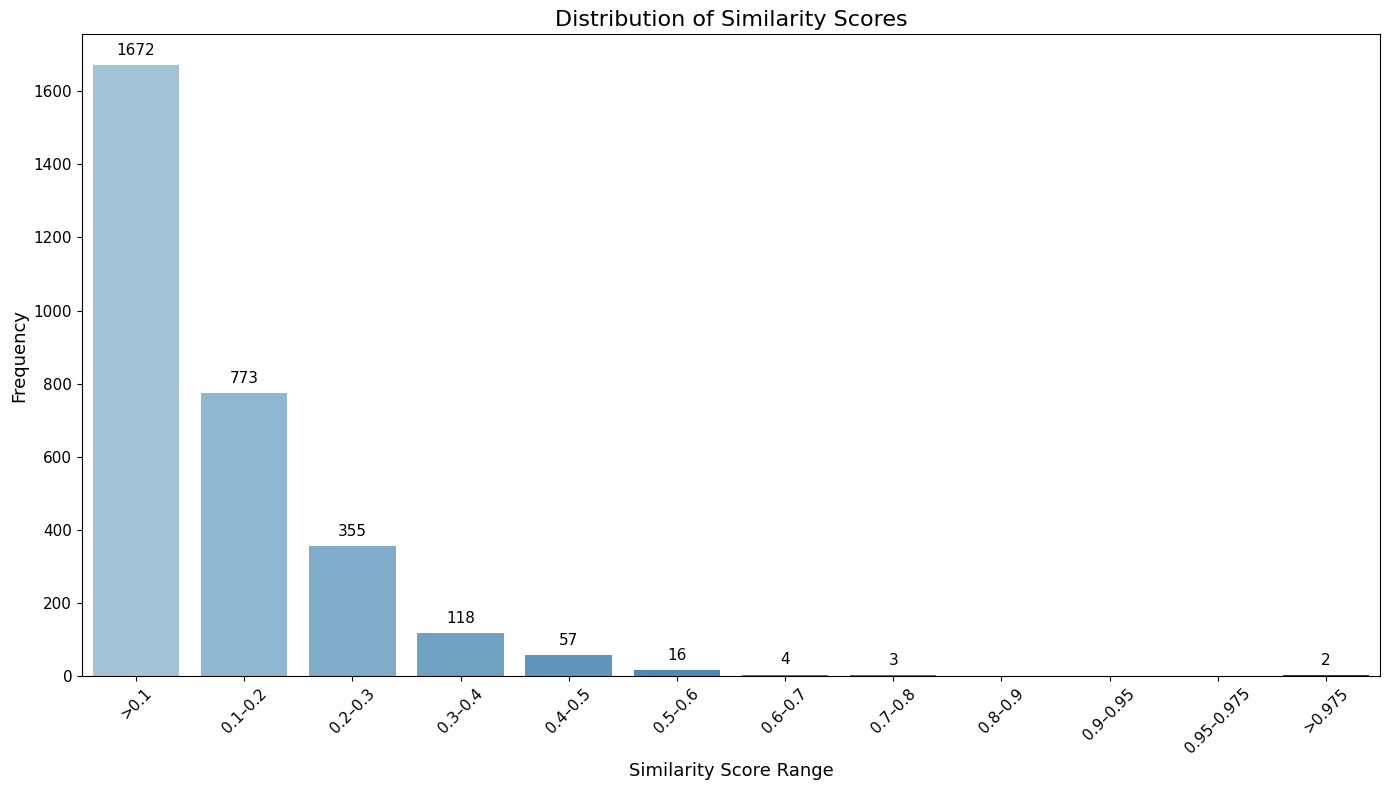

In [27]:
# Distribution of Similarity Scores Visualized

import matplotlib.pyplot as plt
import seaborn as sns


# Manually count per bin as per your prints
counts = [
    len([j for i, j in similarity_score.items() if j < 0.1]),
    len([j for i, j in similarity_score.items() if 0.1 < j < 0.2]),
    len([j for i, j in similarity_score.items() if 0.2 < j < 0.3]),
    len([j for i, j in similarity_score.items() if 0.3 < j < 0.4]),
    len([j for i, j in similarity_score.items() if 0.4 < j < 0.5]),
    len([j for i, j in similarity_score.items() if 0.5 < j < 0.6]),
    len([j for i, j in similarity_score.items() if 0.6 < j < 0.7]),
    len([j for i, j in similarity_score.items() if 0.7 < j < 0.8]),
    len([j for i, j in similarity_score.items() if 0.8 < j < 0.9]),
    len([j for i, j in similarity_score.items() if 0.9 < j < 0.95]),
    len([j for i, j in similarity_score.items() if 0.95 < j < 0.975]),
    len([j for i, j in similarity_score.items() if j > 0.975])
]

labels = [
    '>0.1', '0.1–0.2', '0.2–0.3', '0.3–0.4', '0.4–0.5',
    '0.5–0.6', '0.6–0.7', '0.7–0.8', '0.8–0.9', '0.9–0.95',
    '0.95–0.975', '>0.975'
]

# Plot
plt.figure(figsize=(14, 8))
bars = sns.barplot(x=labels, y=counts, palette="Blues_d")

# Add counts on top of bars
for bar, count in zip(bars.patches, counts):
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 20,
                 str(count), ha='center', va='bottom', color='black', fontsize=11)

plt.title('Distribution of Similarity Scores', fontsize=16)
plt.xlabel('Similarity Score Range', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


C:\Users\jnoot\AppData\Local\Temp\ipykernel_12924\3152525946.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=labels, y=counts, palette="Blues_d")


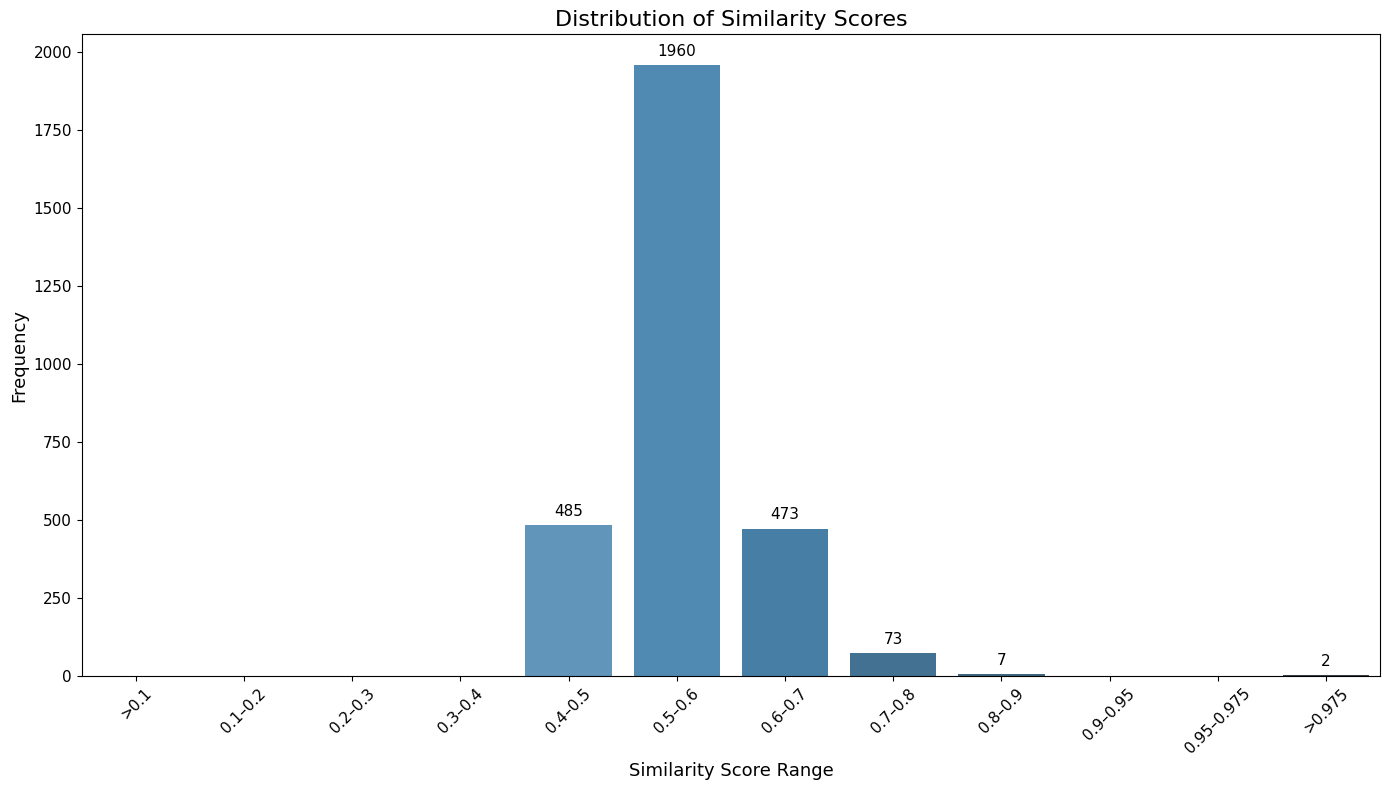

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Manually count per bin as per your prints
counts = [
    len([j for i, j in similarity_score_normalized.items() if j < 0.1]),
    len([j for i, j in similarity_score_normalized.items() if 0.1 < j < 0.2]),
    len([j for i, j in similarity_score_normalized.items() if 0.2 < j < 0.3]),
    len([j for i, j in similarity_score_normalized.items() if 0.3 < j < 0.4]),
    len([j for i, j in similarity_score_normalized.items() if 0.4 < j < 0.5]),
    len([j for i, j in similarity_score_normalized.items() if 0.5 < j < 0.6]),
    len([j for i, j in similarity_score_normalized.items() if 0.6 < j < 0.7]),
    len([j for i, j in similarity_score_normalized.items() if 0.7 < j < 0.8]),
    len([j for i, j in similarity_score_normalized.items() if 0.8 < j < 0.9]),
    len([j for i, j in similarity_score_normalized.items() if 0.9 < j < 0.95]),
    len([j for i, j in similarity_score_normalized.items() if 0.95 < j < 0.975]),
    len([j for i, j in similarity_score_normalized.items() if j > 0.975])
]

labels = [
    '>0.1', '0.1–0.2', '0.2–0.3', '0.3–0.4', '0.4–0.5',
    '0.5–0.6', '0.6–0.7', '0.7–0.8', '0.8–0.9', '0.9–0.95',
    '0.95–0.975', '>0.975'
]

# Plot
plt.figure(figsize=(14, 8))
bars = sns.barplot(x=labels, y=counts, palette="Blues_d")

# Add counts on top of bars
for bar, count in zip(bars.patches, counts):
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 20,
                 str(count), ha='center', va='bottom', color='black', fontsize=11)

plt.title('Distribution of Similarity Scores', fontsize=16)
plt.xlabel('Similarity Score Range', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


In [11]:
df['text1'][50]

'broadband fuels online expression fast web access is encouraging more people to express themselves online  research suggests.  a quarter of broadband users in britain regularly upload content and have personal sites  according to a report by uk think-tank demos. it said that having an always-on  fast connection is changing the way people use the internet. more than five million households in the uk have broadband and that number is growing fast.  the demos report looked at the impact of broadband on people s net habits. it found that more than half of those with broadband logged on to the web before breakfast. one in five even admitted to getting up in the middle of the night to browse the web.  more significantly  argues the report  broadband is encouraging people to take a more active role online. it found that one in five post something on the net everyday  ranging from comments or opinions on sites to uploading photographs.  broadband is putting the  me  in media as it shifts powe

In [12]:
df['text2'][50]

'security warning over  fbi virus  the us federal bureau of investigation is warning that a computer virus is being spread via e-mails that purport to be from the fbi.  the e-mails show that they have come from an fbi.gov address and tell recipients that they have accessed illegal websites. the messages warn that their internet use has been monitored by the fbi s internet fraud complaint center. an attachment in the e-mail contains the virus  the fbi said. the message asks recipients to click on the attachment and answer some questions about their internet use. but rather than being a questionnaire  the attachment contains a virus that infects the recipient s computer  according to the agency. it is not clear what the virus does once it has infected a computer. users are warned never to open attachment from unsolicited e-mails or from people they do not know.   recipients of this or similar solicitations should know that the fbi does not engage in the practice of sending unsolicited e-

In [13]:
similarity_score[50]

0.5914127826690674

In [ ]:
# There is better accuracy or cosine similarity value, Although keeping it -1 to 1 is ideal, for the purpose of assignments its converted as 0 to 1

In [5]:
# Import libraries
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# Load tokenizer and model
model_name = "microsoft/deberta-v3-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Define similarity function
def get_similarity(text1, text2):
    # Tokenize inputs
    inputs = tokenizer([text1, text2], padding=True, truncation=True, return_tensors="pt")
    
    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)

    # Use [CLS] token embeddings (first token)
    embeddings = outputs.last_hidden_state[:, 0, :]  # shape: (2, hidden_size)
    emb1, emb2 = embeddings[0], embeddings[1]
    
    # Normalize and compute cosine similarity
    similarity = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
    
    # Clip to [0, 1] range
    similarity = max(0.0, similarity)
    return round(similarity, 3)

print("Similarity score:", get_similarity(df['text1'][0], df['text2'][0]))


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Similarity score: 0.983


In [ ]:
## We can conclude all-mpnet-base-v2 is accurate for semantic similarity between long-form texts of 300-400 words on average.